## Human In the Loop MiddleWare


In [38]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware

In [39]:
@tool
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"


@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

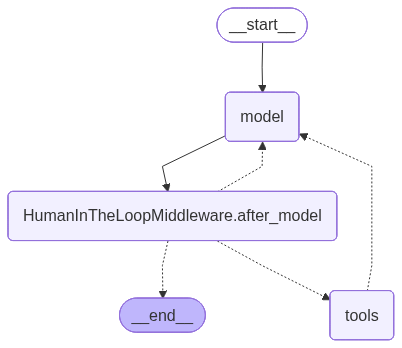

In [40]:
agent = create_agent(
    model="ollama:llama3.2:latest",
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False,

            }
        )
    ]
)

agent

## 1. Approving the request from the human


In [41]:
config = {"configurable": {"thread_id": "123"}}

# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(
        content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='9d02c1d7-aa2a-4623-99be-f4af68cff64f'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-07-10T09:56:22.0140024Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2003919700, 'load_duration': 178783800, 'prompt_eval_count': 231, 'prompt_eval_duration': 448332000, 'eval_count': 27, 'eval_duration': 1327916000, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019f4b74-e5a7-7591-8c5e-e086c33b94a9-0', tool_calls=[{'name': 'send_email_tool', 'args': {'subject': 'Hello', 'recipient': 'john@test.com', 'body': 'How are you?'}, 'id': '02938b8d-d169-4303-acca-93020dff9568', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'output_tokens': 27, 'total_tokens': 258})],
 '__interrupt__': [Interrupt

In [42]:
from langgraph.types import Command

# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )

    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: from email.message import Message
import smtplib

def send_email(recipient, subject, body):
    msg = Message()
    msg['Subject'] = subject
    msg['From'] = 'your-email@gmail.com'
    msg['To'] = recipient
    msg.set_content(body)
    server = smtplib.SMTP('smtp.gmail.com', 587)
    server.starttls()
    server.login(msg['From'], 'your-password')
    server.sendmail(msg['From'], [recipient], msg.as_string())
    server.quit()

send_email('john@test.com', 'Hello', 'How are you?')


In [43]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='9d02c1d7-aa2a-4623-99be-f4af68cff64f'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-07-10T09:56:22.0140024Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2003919700, 'load_duration': 178783800, 'prompt_eval_count': 231, 'prompt_eval_duration': 448332000, 'eval_count': 27, 'eval_duration': 1327916000, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019f4b74-e5a7-7591-8c5e-e086c33b94a9-0', tool_calls=[{'name': 'send_email_tool', 'args': {'subject': 'Hello', 'recipient': 'john@test.com', 'body': 'How are you?'}, 'id': '02938b8d-d169-4303-acca-93020dff9568', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'output_tokens': 27, 'total_tokens': 258}),
  ToolMessage(content="Email 

## 2. Rejecting the request from the human


In [44]:
config = {"configurable": {"thread_id": "456"}}

# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(
        content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='37222adb-2118-4830-b949-04988ca6d210'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-07-10T09:56:30.9463298Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2019398700, 'load_duration': 186800400, 'prompt_eval_count': 231, 'prompt_eval_duration': 77804000, 'eval_count': 27, 'eval_duration': 1716324000, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019f4b75-087e-7782-94c2-2aa99891ce6e-0', tool_calls=[{'name': 'send_email_tool', 'args': {'subject': 'Hello', 'body': 'How are you?', 'recipient': 'john@test.com'}, 'id': '46e4bca6-139e-437b-926b-dc3586be6dc5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'output_tokens': 27, 'total_tokens': 258})],
 '__interrupt__': [Interrupt(

In [45]:
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Rejecting...")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )

    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Rejecting...
✅ Result: 


In [46]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='37222adb-2118-4830-b949-04988ca6d210'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-07-10T09:56:30.9463298Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2019398700, 'load_duration': 186800400, 'prompt_eval_count': 231, 'prompt_eval_duration': 77804000, 'eval_count': 27, 'eval_duration': 1716324000, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019f4b75-087e-7782-94c2-2aa99891ce6e-0', tool_calls=[{'name': 'send_email_tool', 'args': {'subject': 'Hello', 'body': 'How are you?', 'recipient': 'john@test.com'}, 'id': '46e4bca6-139e-437b-926b-dc3586be6dc5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'output_tokens': 27, 'total_tokens': 258}),
  ToolMessage(content='User re

## 3. Editing the request from the human

In [47]:
config = {"configurable": {"thread_id": "789"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [48]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='5d8dd1d0-f1f9-4785-aee7-dccef5bf751d'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-07-10T09:56:35.7725093Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2052498100, 'load_duration': 171741400, 'prompt_eval_count': 229, 'prompt_eval_duration': 339742000, 'eval_count': 30, 'eval_duration': 1507536000, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019f4b75-1b37-7441-8b77-5e1fb0cb5393-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body': 'Hello', 'recipient': 'wrong@email.com', 'subject': 'Test'}, 'id': '06c57e0d-f40d-47c5-b0bc-f8f2e99c9c26', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 229, 'output_tokens': 30, 'total_tokens': 259})],
 '__interrupt__': [Interrupt(value={'act

In [49]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: I apologize for the mistake in the initial response. Here is the corrected response:

I used the `send_email_tool` to send an email to `correct@email.com`. However, I noticed that you provided an incorrect email address `wrong@email.com` earlier. If you would like to resend the email to the correct recipient, please provide the updated email address.

If you'd like to resend the email with the subject 'Corrected Subject' and body 'Hello', here is the corrected response:

The email was sent successfully. The content of the email is:
Subject: Corrected Subject
Body: Hello


In [50]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='5d8dd1d0-f1f9-4785-aee7-dccef5bf751d'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-07-10T09:56:35.7725093Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2052498100, 'load_duration': 171741400, 'prompt_eval_count': 229, 'prompt_eval_duration': 339742000, 'eval_count': 30, 'eval_duration': 1507536000, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019f4b75-1b37-7441-8b77-5e1fb0cb5393-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {'recipient': 'correct@email.com', 'subject': 'Corrected Subject', 'body': 'This was edited by human before sending'}, 'id': '06c57e0d-f40d-47c5-b0bc-f8f2e99c9c26'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 229, 'output_tokens': 30, 'total_tokens':